In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import re
from collections import Counter
import math
from matplotlib.cm import get_cmap
import matplotlib.patches as mpatches
from pathlib import Path

In [2]:
WORKING_DIR="C:/Users/luqma/AI6130/AI6130_Assignment2/"
DATA_DIR = Path(WORKING_DIR,"result")  # Directory containing JSON files
ADAPTERS = ['LoRA', 'AdapterP', 'AdapterH', 'Parallel']
DATASETS = ['AddSub', 'AQuA', 'MultiArith', 'SingleEq']
MODELS = ['ollama', 'tinyllama']
OUTPUT_DIR = './visualizations'

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
def load_data_files():
    """
    Load all JSON files from the data directory and organize by adapter, dataset, and model.
    
    Returns:
        dict: A nested dictionary with structure {model: {adapter: {dataset: data}}}
    """
    all_data = {}
    
    # Check if directory exists
    if not os.path.exists(DATA_DIR):
        print(f"Directory {DATA_DIR} not found. Using example data instead.")
        # Use the example data from openllama-AdapterP-AddSub.json
        example_file_path = "ollama-AdapterP-AddSub.json"
        try:
            with open(example_file_path, 'r') as f:
                example_data = json.load(f)
                all_data = {'ollama': {'AdapterP': {'AddSub': example_data}}}
            return all_data
        except FileNotFoundError:
            print(f"Example file {example_file_path} not found.")
            return {}
    
    # Process each file in the directory
    for filename in os.listdir(DATA_DIR):
        if filename.endswith('.json'):
            for model in MODELS:
                if model in filename:
                    model_name = model
                    break
            else:
                continue  # Skip if model not found in filename
                
            for adapter in ADAPTERS:
                if adapter in filename:
                    adapter_name = adapter
                    break
            else:
                continue  # Skip if adapter not found in filename
                
            for dataset in DATASETS:
                if dataset in filename:
                    dataset_name = dataset
                    break
            else:
                continue  # Skip if dataset not found in filename
            
            # Load the JSON file
            file_path = os.path.join(DATA_DIR, filename)
            try:
                with open(file_path, 'r') as f:
                    data = json.load(f)
                
                # Initialize nested dictionaries if they don't exist
                if model_name not in all_data:
                    all_data[model_name] = {}
                if adapter_name not in all_data[model_name]:
                    all_data[model_name][adapter_name] = {}
                
                all_data[model_name][adapter_name][dataset_name] = data
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return all_data

In [10]:
def create_accuracy_table(all_data):
    """
    Extract and calculate accuracy percentages for all model-adapter-dataset combinations.
    
    Args:
        all_data (dict): Nested dictionary containing the loaded JSON data.
        
    Returns:
        pandas.DataFrame: DataFrame with accuracy metrics in a tabular format.
        
    Note:
        This function works with the data structure from load_data_files()
    """
    accuracy_data = []
    
    for model in all_data:
        for adapter in all_data[model]:
            for dataset in all_data[model][adapter]:
                data = all_data[model][adapter][dataset]
                
                total_questions = len(data)
                correct_answers = sum(1 for item in data if item.get('flag', False))
                
                if total_questions > 0:
                    accuracy = correct_answers / total_questions * 100
                else:
                    accuracy = 0
                
                accuracy_data.append({
                    'Model': model,
                    'Adapter': adapter,
                    'Dataset': dataset,
                    'Accuracy': round(accuracy, 2),
                    'Correct': correct_answers,
                    'Total': total_questions
                })
    
    # Create DataFrame
    df = pd.DataFrame(accuracy_data)
    
    # Create a pivot table for easier viewing
    pivot_df = df.pivot_table(
        index=['Model', 'Adapter'], 
        columns='Dataset', 
        values='Accuracy',
        aggfunc='first'  # Use 'first' since each combination should be unique
    ).reset_index()
    
    # Add mean accuracy across datasets
    pivot_df['Mean'] = pivot_df[DATASETS].mean(axis=1)
    
    # Round values for better display
    for col in pivot_df.columns:
        if col not in ['Model', 'Adapter']:
            pivot_df[col] = pivot_df[col].round(2)
    
    # Return both the raw data and the pivoted table
    return df, pivot_df

def export_accuracy_table(pivot_df, output_file='accuracy_table.csv'):
    """
    Export the accuracy table to a CSV file.
    
    Args:
        pivot_df (pandas.DataFrame): Pivoted DataFrame with accuracy metrics.
        output_file (str): Output file path for the CSV.
    """
    output_path = os.path.join(OUTPUT_DIR, output_file)
    pivot_df.to_csv(output_path, index=False)
    print(f"Accuracy table exported to {output_path}")
    
    return pivot_df

In [11]:
# After loading your data
all_data = load_data_files()

# Generate the accuracy tables
raw_accuracy_df, pivot_accuracy_df = create_accuracy_table(all_data)

# Display the pivoted table in the notebook
display(pivot_accuracy_df)

# Optionally export to CSV
export_accuracy_table(pivot_accuracy_df)

Dataset,Model,Adapter,AQuA,AddSub,MultiArith,SingleEq,Mean
0,ollama,AdapterP,19.29,38.73,68.83,47.05,43.47
1,ollama,LoRA,16.54,38.73,65.33,48.62,42.30
2,ollama,Parallel,19.29,37.72,66.50,41.93,41.36
3,tinyllama,AdapterP,15.35,1.01,3.50,0.59,5.11
4,tinyllama,LoRA,24.41,2.53,3.50,0.59,7.76
5,tinyllama,Parallel,18.11,1.01,3.33,0.59,5.76


Accuracy table exported to ./visualizations\accuracy_table.csv


Dataset,Model,Adapter,AQuA,AddSub,MultiArith,SingleEq,Mean
0,ollama,AdapterP,19.29,38.73,68.83,47.05,43.47
1,ollama,LoRA,16.54,38.73,65.33,48.62,42.30
2,ollama,Parallel,19.29,37.72,66.50,41.93,41.36
3,tinyllama,AdapterP,15.35,1.01,3.50,0.59,5.11
4,tinyllama,LoRA,24.41,2.53,3.50,0.59,7.76
5,tinyllama,Parallel,18.11,1.01,3.33,0.59,5.76


In [12]:
def calculate_accuracy_metrics(all_data):
    """
    Calculate accuracy metrics for each model-adapter-dataset combination.
    
    Args:
        all_data (dict): Nested dictionary containing the loaded JSON data.
        
    Returns:
        pandas.DataFrame: DataFrame with accuracy metrics.
    """
    accuracy_data = []
    
    for model in all_data:
        for adapter in all_data[model]:
            for dataset in all_data[model][adapter]:
                data = all_data[model][adapter][dataset]
                
                total_questions = len(data)
                correct_answers = sum(1 for item in data if item.get('flag', False))
                
                if total_questions > 0:
                    accuracy = correct_answers / total_questions * 100
                else:
                    accuracy = 0
                
                accuracy_data.append({
                    'Model': model,
                    'Adapter': adapter,
                    'Dataset': dataset,
                    'Accuracy': accuracy,
                    'Correct': correct_answers,
                    'Total': total_questions
                })
    
    return pd.DataFrame(accuracy_data)

In [13]:
def extract_question_metrics(all_data):
    """
    Extract metrics related to question complexity and error magnitude.
    
    Args:
        all_data (dict): Nested dictionary containing the loaded JSON data.
        
    Returns:
        pandas.DataFrame: DataFrame with question metrics.
    """
    question_metrics = []
    
    for model in all_data:
        for adapter in all_data[model]:
            for dataset in all_data[model][adapter]:
                data = all_data[model][adapter][dataset]
                
                for item in data:
                    instruction = item.get('instruction', '')
                    answer = item.get('answer', 0)
                    prediction = item.get('pred', 0)
                    is_correct = item.get('flag', False)
                    
                    # Calculate metrics
                    word_count = len(instruction.split())
                    number_count = len(re.findall(r'[-+]?\d*\.\d+|\d+', instruction))
                    
                    # Handle cases where answer or prediction might be strings
                    try:
                        answer_val = float(answer) if isinstance(answer, str) else answer
                        pred_val = float(prediction) if isinstance(prediction, str) else prediction
                        
                        if answer_val != 0:
                            error_percentage = abs((pred_val - answer_val) / answer_val) * 100
                        else:
                            error_percentage = abs(pred_val - answer_val) * 100
                    except (ValueError, TypeError):
                        error_percentage = 100 if not is_correct else 0
                    
                    # Determine operation type (simple heuristic)
                    operation = 'unknown'
                    if 'add' in instruction.lower() or '+' in instruction or 'sum' in instruction.lower() or 'total' in instruction.lower():
                        operation = 'addition'
                    elif 'subtract' in instruction.lower() or '-' in instruction or 'difference' in instruction.lower() or 'less' in instruction.lower():
                        operation = 'subtraction'
                    elif 'multiply' in instruction.lower() or '*' in instruction or 'product' in instruction.lower() or 'times' in instruction.lower():
                        operation = 'multiplication'
                    elif 'divide' in instruction.lower() or '/' in instruction or 'quotient' in instruction.lower() or 'per' in instruction.lower():
                        operation = 'division'
                    elif 'more' in instruction.lower() or 'left' in instruction.lower():
                        operation = 'subtraction'
                    elif 'together' in instruction.lower() or 'combined' in instruction.lower() or 'in total' in instruction.lower() or 'in all' in instruction.lower():
                        operation = 'addition'
                    
                    question_metrics.append({
                        'Model': model,
                        'Adapter': adapter,
                        'Dataset': dataset,
                        'Word_Count': word_count,
                        'Number_Count': number_count,
                        'Is_Correct': is_correct,
                        'Error_Percentage': min(error_percentage, 100),  # Cap at 100% for visualization
                        'Operation': operation,
                        'Answer': answer_val if isinstance(answer_val, (int, float)) else 0,
                        'Prediction': pred_val if isinstance(pred_val, (int, float)) else 0
                    })
    
    return pd.DataFrame(question_metrics)

In [14]:
def categorize_errors(row):
    """
    Categorize the type of error made in a prediction.
    
    Args:
        row (pandas.Series): Row from the question metrics DataFrame.
        
    Returns:
        str: Error category.
    """
    if row['Is_Correct']:
        return 'Correct'
    
    error_pct = row['Error_Percentage']
    
    if error_pct <= 5:
        return 'Almost Correct (<5%)'
    elif error_pct <= 20:
        return 'Close (5-20%)'
    elif error_pct <= 50:
        return 'Off (20-50%)'
    elif error_pct < 100:
        return 'Far Off (50-99%)'
    else:
        return 'Completely Wrong (=100%)'


In [15]:
def plot_adapter_performance_by_model(accuracy_df, output_dir=OUTPUT_DIR, output_file='combined_adapter_performance.png'):
    """
    Create side-by-side grouped bar charts showing accuracy of different adapters across datasets for each model.
    
    Args:
        accuracy_df (pandas.DataFrame): DataFrame with accuracy metrics.
        output_dir (str): Output directory for the visualizations.
        output_file (str): Filename for the combined visualization.
    """
    # Get unique models
    models = accuracy_df['Model'].unique()
    
    # Create a single figure with two subplots side by side
    fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)
    
    # Set up the common style
    sns.set_style("whitegrid")
    
    for i, model in enumerate(models):
        # Filter data for current model
        model_data = accuracy_df[accuracy_df['Model'] == model]
        
        # Group by dataset and adapter, calculate mean accuracy
        plot_data = model_data.groupby(['Dataset', 'Adapter'])['Accuracy'].mean().reset_index()
        
        # Create the grouped bar chart on the appropriate subplot
        chart = sns.barplot(x='Dataset', y='Accuracy', hue='Adapter', data=plot_data, 
                           palette='viridis', ax=axes[i])
        
        # Add labels and title
        # Format model name for title (capitalize first letter of each word)
        model_display = ' '.join(word.capitalize() for word in model.split('_'))
        axes[i].set_title(f'{model_display} Performance', fontsize=16)
        axes[i].set_xlabel('Dataset', fontsize=14)
        
        # Only set y-label for the first subplot to avoid redundancy
        if i == 0:
            axes[i].set_ylabel('Accuracy (%)', fontsize=14)
        else:
            axes[i].set_ylabel('')
        
        # Set appropriate y-axis limit based on the model
        if 'tiny' in model.lower():
            axes[i].set_ylim(0, 30)  # Adjust for TinyLlama's lower scores
        else:
            axes[i].set_ylim(0, 80)  # Higher limit for OpenLLaMA
        
        # Add value labels on top of bars
        for container in chart.containers:
            chart.bar_label(container, fmt='%.1f', fontsize=10)
        
        # Add a horizontal grid for better readability
        axes[i].grid(axis='y', alpha=0.3)
        
        # Only add legend to the second subplot to save space
        if i == 1:
            axes[i].legend(title='Adapter Type', fontsize=12, title_fontsize=14)
        else:
            axes[i].get_legend().remove()
    
    # Add a common legend outside the subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05),
              fancybox=True, shadow=True, ncol=len(labels), fontsize=12, title='Adapter Type', title_fontsize=14)
    
    # Add overall title
    fig.suptitle('Adapter Performance Comparison Across Models', fontsize=18, y=0.98)
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Make room for the shared legend at the bottom
    plt.savefig(os.path.join(output_dir, output_file), dpi=800, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_error_by_complexity_by_model(question_metrics_df, output_dir=OUTPUT_DIR):
    """
    Create separate scatter plots showing error magnitude vs question complexity for each model.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_dir (str): Output directory for the visualizations.
    """
    # Get unique models
    models = question_metrics_df['Model'].unique()
    
    for model in models:
        # Filter data for current model
        model_data = question_metrics_df[question_metrics_df['Model'] == model]
        
        # Create output filename
        output_file = f'{model}_error_by_complexity.png'
        
        plt.figure(figsize=(12, 7))
        
        # Set up the plot
        sns.set_style("whitegrid")
        
        # Create a scatter plot
        scatter = sns.scatterplot(x='Word_Count', y='Error_Percentage', 
                                 hue='Adapter', style='Dataset',
                                 alpha=0.7, s=100, data=model_data)
        
        # Add regression lines for each adapter
        adapters = model_data['Adapter'].unique()
        for adapter in adapters:
            adapter_data = model_data[model_data['Adapter'] == adapter]
            sns.regplot(x='Word_Count', y='Error_Percentage', data=adapter_data,
                       scatter=False, line_kws={"alpha": 0.7, "lw": 2})
        
        # Add labels and title
        # Format model name for title
        model_display = ' '.join(word.capitalize() for word in model.split('_'))
        plt.title(f'Error Magnitude vs. Question Complexity for {model_display}', fontsize=16)
        plt.xlabel('Question Word Count', fontsize=14)
        plt.ylabel('Error Percentage (%)', fontsize=14)
        
        # Set appropriate y-axis limit based on model (TinyLlama will likely have higher errors)
        if 'tiny' in model.lower():
            plt.ylim(0, 100)  # Full scale for TinyLlama's likely higher errors
        else:
            plt.ylim(0, 100)  # Same scale, but could be adjusted if needed
        
        # Customize legend
        plt.legend(title='Adapter & Dataset', fontsize=12, title_fontsize=14)
        
        # Adjust layout and save
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, output_file), dpi=500, bbox_inches='tight')
        plt.show()
        plt.close()

def plot_prediction_deviation_by_model(question_metrics_df, output_dir=OUTPUT_DIR):
    """
    Create separate box plots showing the distribution of prediction deviations for each model.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_dir (str): Output directory for the visualizations.
    """
    # Calculate relative deviation
    question_metrics_df['Deviation'] = (question_metrics_df['Prediction'] - question_metrics_df['Answer'])
    
    # Get unique models
    models = question_metrics_df['Model'].unique()
    
    for model in models:
        # Filter data for current model
        model_data = question_metrics_df[question_metrics_df['Model'] == model]
        
        # Create output filename
        output_file = f'{model}_prediction_deviation.png'
        
        # Filter out extreme outliers for better visualization
        # Use robust statistics (IQR) to determine outliers for this model
        Q1 = model_data['Deviation'].quantile(0.25)
        Q3 = model_data['Deviation'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        filtered_df = model_data[(model_data['Deviation'] >= lower_bound) & 
                                 (model_data['Deviation'] <= upper_bound)]
        
        plt.figure(figsize=(12, 7))
        
        # Create a box plot
        sns.boxplot(x='Adapter', y='Deviation', hue='Dataset', data=filtered_df, 
                    palette='viridis', showfliers=True)
        
        # Add a horizontal line at zero (perfect prediction)
        plt.axhline(y=0, color='r', linestyle='-', alpha=0.7)
        
        # Add labels and title
        # Format model name for title
        model_display = ' '.join(word.capitalize() for word in model.split('_'))
        plt.title(f'Distribution of Prediction Deviations for {model_display}', fontsize=16)
        plt.xlabel('Adapter', fontsize=14)
        plt.ylabel('Deviation (Predicted - Actual)', fontsize=14)
        
        # Set appropriate y-axis limits based on the filtered data
        min_val = filtered_df['Deviation'].min()
        max_val = filtered_df['Deviation'].max()
        # Add some padding
        y_padding = (max_val - min_val) * 0.1
        plt.ylim(min_val - y_padding, max_val + y_padding)
        
        # Customize legend
        plt.legend(title='Dataset', fontsize=12, title_fontsize=14)
        
        # Adjust layout and save
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, output_file), dpi=500, bbox_inches='tight')
        plt.show()
        plt.close()

In [16]:
def plot_error_confusion_matrix_by_model(question_metrics_df, output_file='error_confusion_matrix_by_model.png'):
    """
    Create a heatmap showing the distribution of error types for each adapter, separated by model.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_file (str): Output file path for the visualization.
    """
    # Add error category column
    question_metrics_df['Error_Category'] = question_metrics_df.apply(categorize_errors, axis=1)
    
    # Create a figure with two subplots (one for each model)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Get unique models
    models = question_metrics_df['Model'].unique()
    
    # Sort the error categories in a logical order
    error_order = ['Correct', 'Almost Correct (<5%)', 'Close (5-20%)', 
                  'Off (20-50%)', 'Far Off (50-99%)', 'Completely Wrong (=100%)']
    
    # Create a custom colormap from green to red
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#2ca02c', '#d62728'], N=100)
    
    for i, model in enumerate(models):
        # Filter data for the current model
        model_data = question_metrics_df[question_metrics_df['Model'] == model]
        
        # Count occurrences of each error category for each adapter within this model
        heatmap_data = model_data.groupby(['Adapter', 'Error_Category']).size().unstack().fillna(0)
        
        # Convert to percentages
        for adapter in heatmap_data.index:
            total = heatmap_data.loc[adapter].sum()
            if total > 0:
                heatmap_data.loc[adapter] = (heatmap_data.loc[adapter].astype(float) / total * 100)
        
        # Reindex to ensure all categories are included and in the right order
        heatmap_data = heatmap_data.reindex(columns=error_order).fillna(0)
        
        # Create the heatmap on the appropriate subplot
        sns.heatmap(heatmap_data, annot=True, cmap=cmap, fmt='.1f',
                    linewidths=0.5, cbar_kws={'label': 'Percentage of Predictions (%)'},
                    ax=axes[i])
        
        # Format model name for title (capitalize)
        model_display = model.capitalize()
        axes[i].set_title(f'Error Distribution for {model_display}', fontsize=14)
        axes[i].set_xlabel('Error Category', fontsize=12)
        axes[i].set_ylabel('Adapter', fontsize=12)
    
    # Add an overall title
    plt.suptitle('Distribution of Prediction Error Types by Model and Adapter', fontsize=16)
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=700, bbox_inches='tight')
    plt.show()
    plt.close()

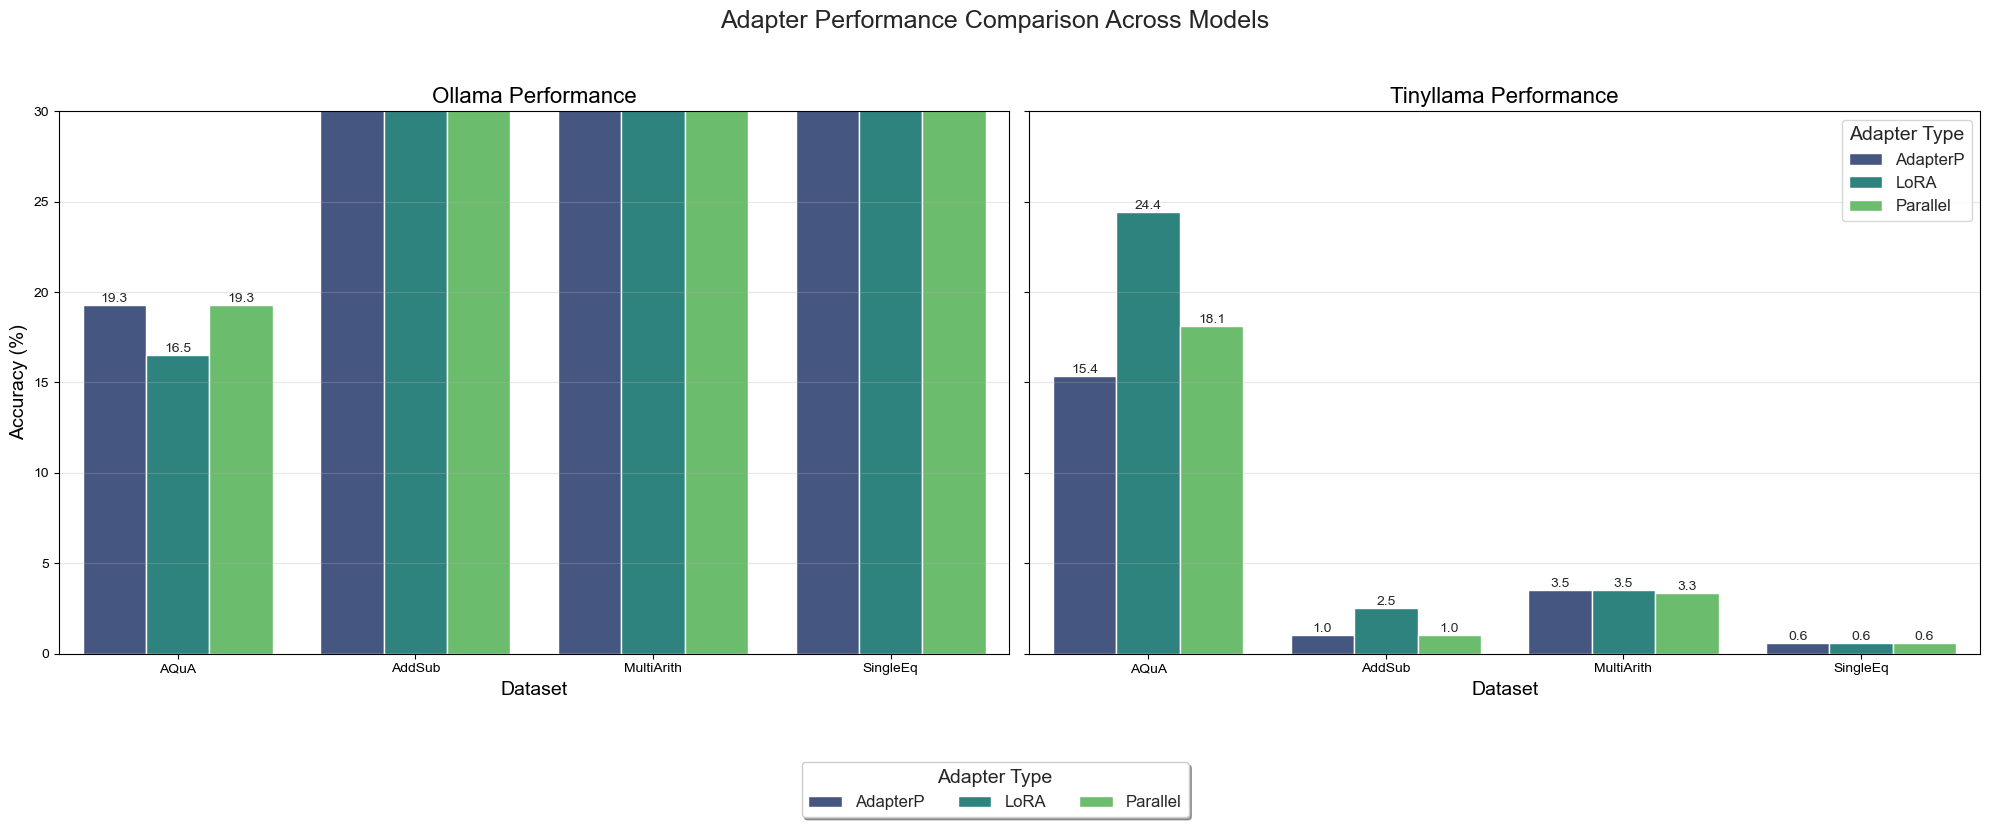

In [17]:
# After loading your data and creating the metrics DataFrames
accuracy_df = calculate_accuracy_metrics(all_data)
question_metrics_df = extract_question_metrics(all_data)

# Create separate visualizations for each model
plot_adapter_performance_by_model(accuracy_df)
#plot_error_by_complexity_by_model(question_metrics_df)
#plot_prediction_deviation_by_model(question_metrics_df)
# After loading your data and creating the metrics DataFrames
#accuracy_df = calculate_accuracy_metrics(all_data)
#question_metrics_df = extract_question_metrics(all_data)

# Create the model-specific error confusion matrix
#plot_error_confusion_matrix_by_model(question_metrics_df)
   
#print("3. Error Type Confusion Matrix...")
#plot_error_confusion_matrix(question_metrics_df)

In [32]:
def plot_adapter_performance(accuracy_df, output_file='adapter_performance.png'):
    """
    Create a grouped bar chart showing accuracy of different adapters across datasets.
    
    Args:
        accuracy_df (pandas.DataFrame): DataFrame with accuracy metrics.
        output_file (str): Output file path for the visualization.
    """
    plt.figure(figsize=(14, 8))
    
    # Set up the plot
    sns.set_style("whitegrid")
    
    # Group by dataset and adapter, calculate mean accuracy
    plot_data = accuracy_df.groupby(['Dataset', 'Adapter'])['Accuracy'].mean().reset_index()
    
    # Create the grouped bar chart
    chart = sns.barplot(x='Dataset', y='Accuracy', hue='Adapter', data=plot_data, 
                         palette='viridis')
    
    # Add labels and title
    plt.title('Adapter Performance Across Datasets', fontsize=16)
    plt.xlabel('Dataset', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.ylim(0, 100)  # Set y-axis to go from 0 to 100%
    
    # Add value labels on top of bars
    for container in chart.containers:
        chart.bar_label(container, fmt='%.1f', fontsize=10)
    
    # Add a horizontal grid for better readability
    plt.grid(axis='y', alpha=0.3)
    
    # Customize legend
    plt.legend(title='Adapter Type', fontsize=12, title_fontsize=14)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_error_by_complexity(question_metrics_df, output_file='error_by_complexity.png'):
    """
    Create a scatter plot showing error magnitude vs question complexity.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_file (str): Output file path for the visualization.
    """
    plt.figure(figsize=(14, 8))
    
    # Set up the plot
    sns.set_style("whitegrid")
    
    # Create a scatter plot
    scatter = sns.scatterplot(x='Word_Count', y='Error_Percentage', 
                              hue='Adapter', style='Dataset',
                              alpha=0.7, s=100, data=question_metrics_df)
    
    # Add regression lines for each adapter
    adapters = question_metrics_df['Adapter'].unique()
    for adapter in adapters:
        adapter_data = question_metrics_df[question_metrics_df['Adapter'] == adapter]
        sns.regplot(x='Word_Count', y='Error_Percentage', data=adapter_data,
                   scatter=False, line_kws={"alpha": 0.7, "lw": 2})
    
    # Add labels and title
    plt.title('Error Magnitude vs. Question Complexity', fontsize=16)
    plt.xlabel('Question Word Count', fontsize=14)
    plt.ylabel('Error Percentage (%)', fontsize=14)
    plt.ylim(0, 100)  # Cap at 100% for better visualization
    
    # Customize legend
    plt.legend(title='Adapter & Dataset', fontsize=12, title_fontsize=14)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_error_confusion_matrix(question_metrics_df, output_file='error_confusion_matrix.png'):
    """
    Create a heatmap showing the distribution of error types for each adapter.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_file (str): Output file path for the visualization.
    """
    # Add error category column
    question_metrics_df['Error_Category'] = question_metrics_df.apply(categorize_errors, axis=1)
    
    # Count occurrences of each error category for each adapter
    heatmap_data = question_metrics_df.groupby(['Adapter', 'Error_Category']).size().unstack().fillna(0)
    heatmap_data = heatmap_data.astype(float)
    
    # Convert to percentages
    for adapter in heatmap_data.index:
        total = heatmap_data.loc[adapter].sum()
        if total > 0:
            heatmap_data.loc[adapter] = (heatmap_data.loc[adapter].astype(float) / total * 100)
    
    # Sort the error categories in a logical order
    error_order = ['Correct', 'Almost Correct (<5%)', 'Close (5-20%)', 
                  'Off (20-50%)', 'Far Off (50-99%)', 'Completely Wrong (=100%)']
    
    # Reindex to ensure all categories are included and in the right order
    heatmap_data = heatmap_data.reindex(columns=error_order).fillna(0)
    
    plt.figure(figsize=(14, 8))
    
    # Create a custom colormap from green to red
    cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#2ca02c', '#d62728'], N=100)
    
    # Create the heatmap
    sns.heatmap(heatmap_data, annot=True, cmap=cmap, fmt='.1f',
                linewidths=0.5, cbar_kws={'label': 'Percentage of Predictions (%)'})
    
    # Add labels and title
    plt.title('Distribution of Prediction Error Types by Adapter', fontsize=16)
    plt.xlabel('Error Category', fontsize=14)
    plt.ylabel('Adapter', fontsize=14)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()


In [8]:

def plot_prediction_deviation(question_metrics_df, output_file='prediction_deviation.png'):
    """
    Create a box plot showing the distribution of prediction deviations for each adapter.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_file (str): Output file path for the visualization.
    """
    # Calculate relative deviation
    question_metrics_df['Deviation'] = (question_metrics_df['Prediction'] - question_metrics_df['Answer'])
    
    # Filter out extreme outliers for better visualization
    # Use robust statistics (IQR) to determine outliers
    Q1 = question_metrics_df['Deviation'].quantile(0.25)
    Q3 = question_metrics_df['Deviation'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    filtered_df = question_metrics_df[(question_metrics_df['Deviation'] >= lower_bound) & 
                                      (question_metrics_df['Deviation'] <= upper_bound)]
    
    plt.figure(figsize=(14, 8))
    
    # Create a box plot
    sns.boxplot(x='Adapter', y='Deviation', hue='Dataset', data=filtered_df, 
                palette='viridis', showfliers=True)
    
    # Add a horizontal line at zero (perfect prediction)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.7)
    
    # Add labels and title
    plt.title('Distribution of Prediction Deviations by Adapter', fontsize=16)
    plt.xlabel('Adapter', fontsize=14)
    plt.ylabel('Deviation (Predicted - Actual)', fontsize=14)
    
    # Customize legend
    plt.legend(title='Dataset', fontsize=12, title_fontsize=14)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_operation_performance_radar(question_metrics_df, output_file='operation_performance_radar.png'):
    """
    Create a radar chart showing adapter performance on different operation types.
    
    Args:
        question_metrics_df (pandas.DataFrame): DataFrame with question metrics.
        output_file (str): Output file path for the visualization.
    """
    # Group by adapter and operation type, calculate accuracy
    operation_accuracy = question_metrics_df.groupby(['Adapter', 'Operation'])['Is_Correct'].mean() * 100
    operation_accuracy = operation_accuracy.reset_index().pivot(index='Adapter', columns='Operation', values='Is_Correct')
    
    # Ensure all operations are included with zeros for missing data
    operations = ['addition', 'subtraction', 'multiplication', 'division', 'unknown']
    for op in operations:
        if op not in operation_accuracy.columns:
            operation_accuracy[op] = 0
    
    # Keep only relevant operations and fill NaNs with zeros
    operation_accuracy = operation_accuracy[operations].fillna(0)
    
    # Set up the radar chart
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, polar=True)
    
    # Number of operations
    N = len(operations)
    
    # Compute angle for each operation
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize the radar plot
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw one axis per operation and add labels
    plt.xticks(angles[:-1], operations, fontsize=12)
    
    # Draw ylabels (accuracy levels)
    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"], fontsize=10)
    plt.ylim(0, 100)
    
    # Get a color map with distinct colors
    cmap = plt.colormaps['viridis']
    colors = [cmap(i) for i in np.linspace(0, 1, len(operation_accuracy))]
    
    # Plot each adapter
    for i, adapter in enumerate(operation_accuracy.index):
        values = operation_accuracy.loc[adapter].tolist()
        values += values[:1]  # Close the loop
        
        # Plot the adapter line
        ax.plot(angles, values, linewidth=2, linestyle='solid', color=colors[i], label=adapter)
        ax.fill(angles, values, color=colors[i], alpha=0.25)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=12)
    
    # Add title
    plt.title('Adapter Performance by Operation Type', fontsize=16, y=1.1)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()


In [12]:
def plot_model_adapter_heatmap(accuracy_df, output_file='model_adapter_heatmap.png'):
    """
    Create a heatmap showing performance of different model-adapter combinations.
    
    Args:
        accuracy_df (pandas.DataFrame): DataFrame with accuracy metrics.
        output_file (str): Output file path for the visualization.
    """
    # Group by Model and Adapter, calculate mean accuracy across datasets
    model_adapter_accuracy = accuracy_df.groupby(['Model', 'Adapter'])['Accuracy'].mean().reset_index()
    
    # Reshape to wide format for heatmap
    heatmap_data = model_adapter_accuracy.pivot(index='Model', columns='Adapter', values='Accuracy')
    
    plt.figure(figsize=(14, 8), dpi=300)  # Higher DPI for LaTeX inclusion
    
    # Create a custom colormap from white to dark blue
    cmap = LinearSegmentedColormap.from_list('custom_blue', ['#ffffff', '#1f77b4'], N=100)
    
    # Create the heatmap with larger text size for better visibility when scaled
    ax = sns.heatmap(heatmap_data, annot=True, cmap=cmap, fmt='.1f',
                linewidths=0.5, annot_kws={"size": 14},
                cbar_kws={'label': 'Average Accuracy (%)'})
    
    # Increase font size for all elements
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
    
    # Add labels and title with larger font
    plt.title('Model Performance with Different Adapters', fontsize=20)
    plt.xlabel('Adapter', fontsize=16)
    plt.ylabel('Model', fontsize=16)
    
    # Make colorbar label larger
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Average Accuracy (%)', size=14)
    
    # Adjust layout and save with high resolution
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_model_dataset_performance(accuracy_df, output_file='model_dataset_performance.png'):
    """
    Create a grouped bar chart showing performance of models across different datasets.
    
    Args:
        accuracy_df (pandas.DataFrame): DataFrame with accuracy metrics.
        output_file (str): Output file path for the visualization.
    """
    # Group by Model and Dataset, calculate mean and std of accuracy across adapters
    grouped_data = accuracy_df.groupby(['Model', 'Dataset']).agg(
        Mean_Accuracy=('Accuracy', 'mean'),
        Std_Accuracy=('Accuracy', 'std')
    ).reset_index()
    
    # Handle NaN values in std (in case there's only one adapter for a model-dataset combo)
    grouped_data['Std_Accuracy'] = grouped_data['Std_Accuracy'].fillna(0)
    
    plt.figure(figsize=(14, 8), dpi=300)  # Higher DPI for LaTeX inclusion
    
    # Set up the plot with larger elements for better visibility
    sns.set_style("whitegrid")
    
    # Determine the positions for each group of bars
    models = grouped_data['Model'].unique()
    datasets = grouped_data['Dataset'].unique()
    
    num_models = len(models)
    bar_width = 0.8 / num_models
    
    # Setup colors
    colors = plt.cm.viridis(np.linspace(0, 1, num_models))
    
    # Create the grouped bar chart manually for more control
    for i, model in enumerate(models):
        model_data = grouped_data[grouped_data['Model'] == model]
        positions = np.arange(len(datasets)) + i * bar_width - (num_models - 1) * bar_width / 2
        
        # Plot bars
        bars = plt.bar(positions, model_data['Mean_Accuracy'], width=bar_width, 
                color=colors[i], label=model)
        
        # Add error bars
        plt.errorbar(positions, model_data['Mean_Accuracy'], yerr=model_data['Std_Accuracy'],
                   fmt='none', ecolor='black', capsize=5, linewidth=1.5)
        
        # Add text labels on top of bars with larger font
        for j, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=12)
    
    # Set the x-tick positions and labels
    plt.xticks(np.arange(len(datasets)), datasets, fontsize=14)
    
    # Add labels and title with larger font
    plt.title('Model Performance Across Datasets', fontsize=20)
    plt.xlabel('Dataset', fontsize=16)
    plt.ylabel('Average Accuracy (%)', fontsize=16)
    plt.ylim(0, 110)  # Leave room for error bars and text labels
    
    # Add a grid for better readability
    plt.grid(axis='y', alpha=0.3)
    
    # Customize legend with larger font
    plt.legend(title='Model', fontsize=14, title_fontsize=16)
    
    # Add a horizontal line at 50% for reference
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Adjust layout and save with high resolution
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, output_file), dpi=500, bbox_inches='tight')
    plt.show()
    plt.close()

In [13]:
def main():
    """
    Main function to run the visualization pipeline.
    """
    print("Loading data files...")
    all_data = load_data_files()
    
    if not all_data:
        print("No data files found or loaded. Exiting.")
        return
    
    print("Calculating accuracy metrics...")
    accuracy_df = calculate_accuracy_metrics(all_data)
    
    print("Extracting question metrics...")
    question_metrics_df = extract_question_metrics(all_data)
    
    print("Creating visualizations...")
    print("1. Adapter Performance Comparison...")
    plot_adapter_performance(accuracy_df)
    
    print("2. Error Analysis by Question Complexity...")
    plot_error_by_complexity(question_metrics_df)
    
    print("3. Error Type Confusion Matrix...")
    plot_error_confusion_matrix(question_metrics_df)
    
    print("4. Prediction Deviation Analysis...")
    plot_prediction_deviation(question_metrics_df)
    
    print("5. Performance by Mathematical Operation...")
    plot_operation_performance_radar(question_metrics_df)
    
    print("6. Model-Adapter Performance Heatmap...")
    plot_model_adapter_heatmap(accuracy_df)
    
    print("7. Model Performance by Dataset...")
    plot_model_dataset_performance(accuracy_df)
    
    print(f"Visualizations saved to {OUTPUT_DIR}")

Loading data files...
Calculating accuracy metrics...
Extracting question metrics...
Creating visualizations...
1. Adapter Performance Comparison...


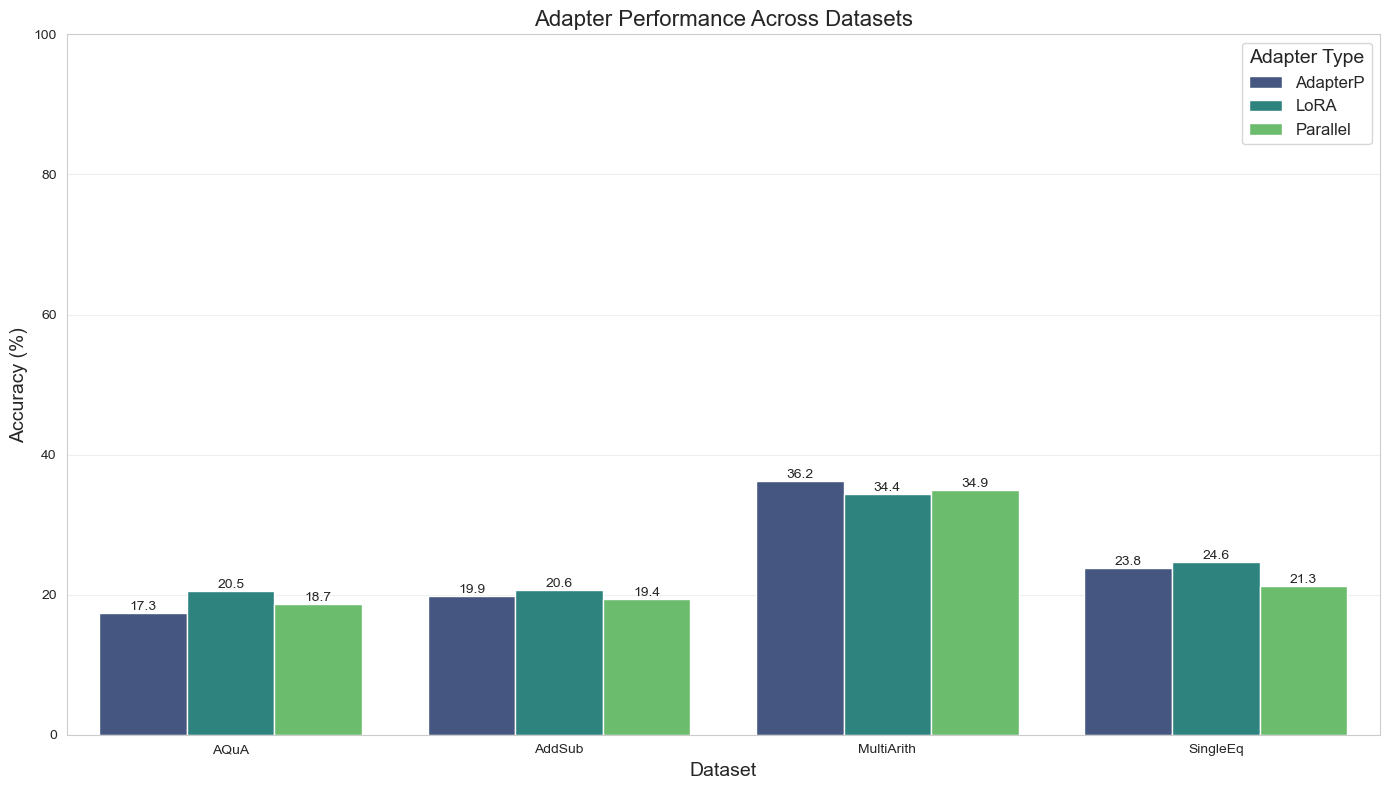

2. Error Analysis by Question Complexity...


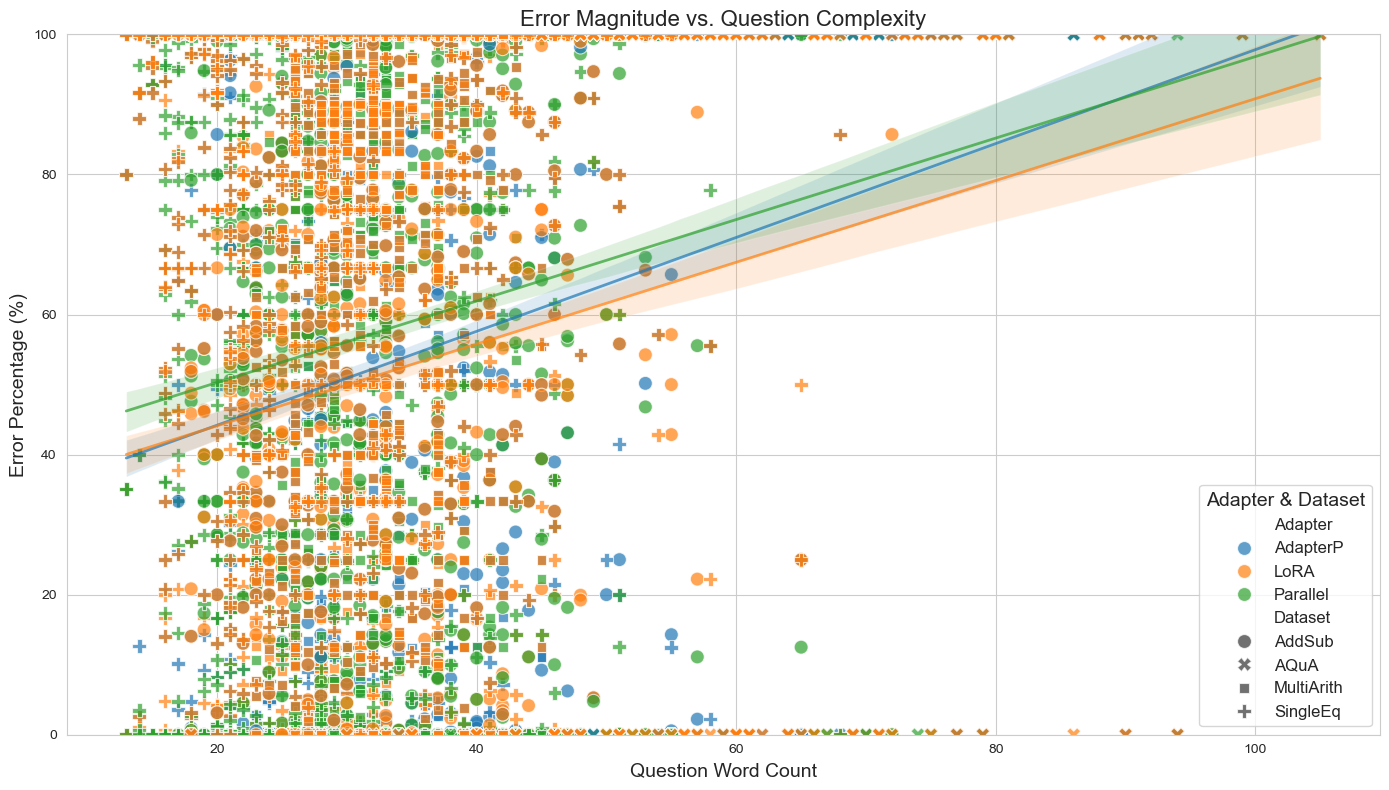

3. Error Type Confusion Matrix...


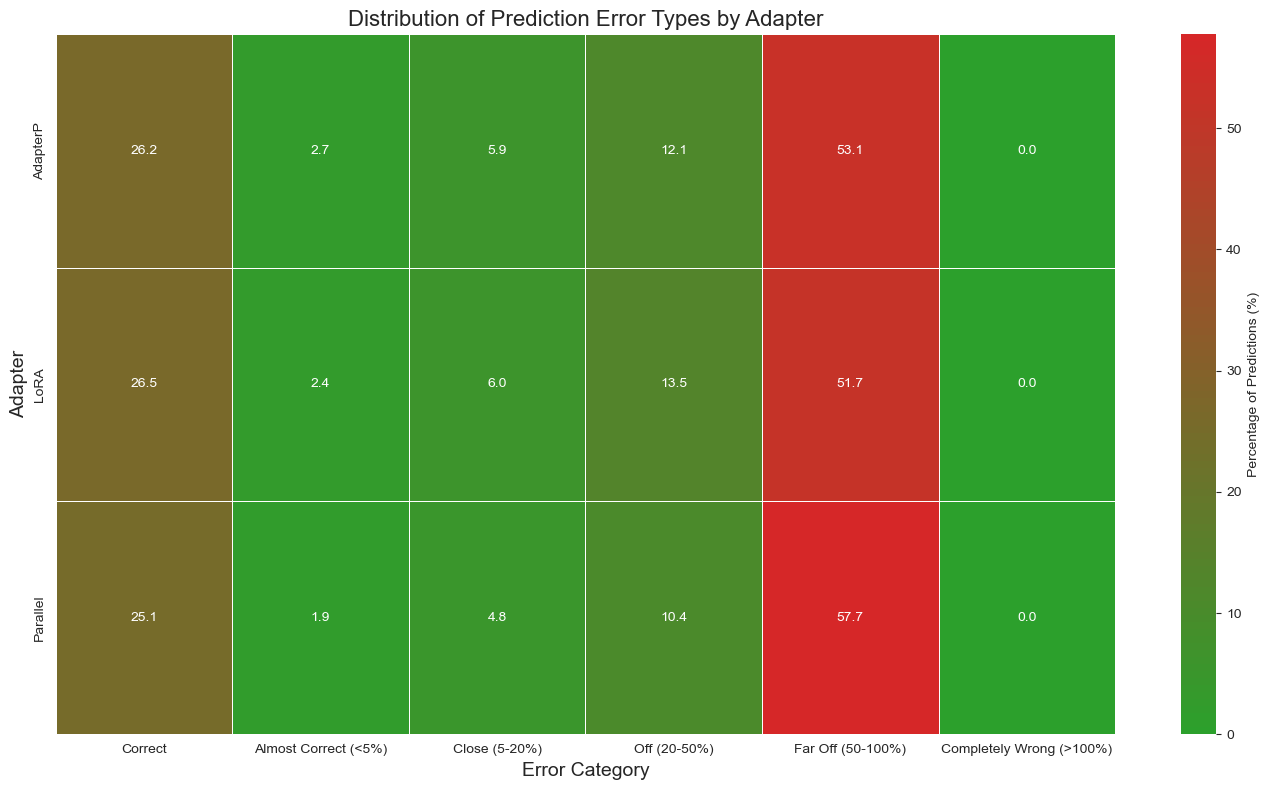

4. Prediction Deviation Analysis...


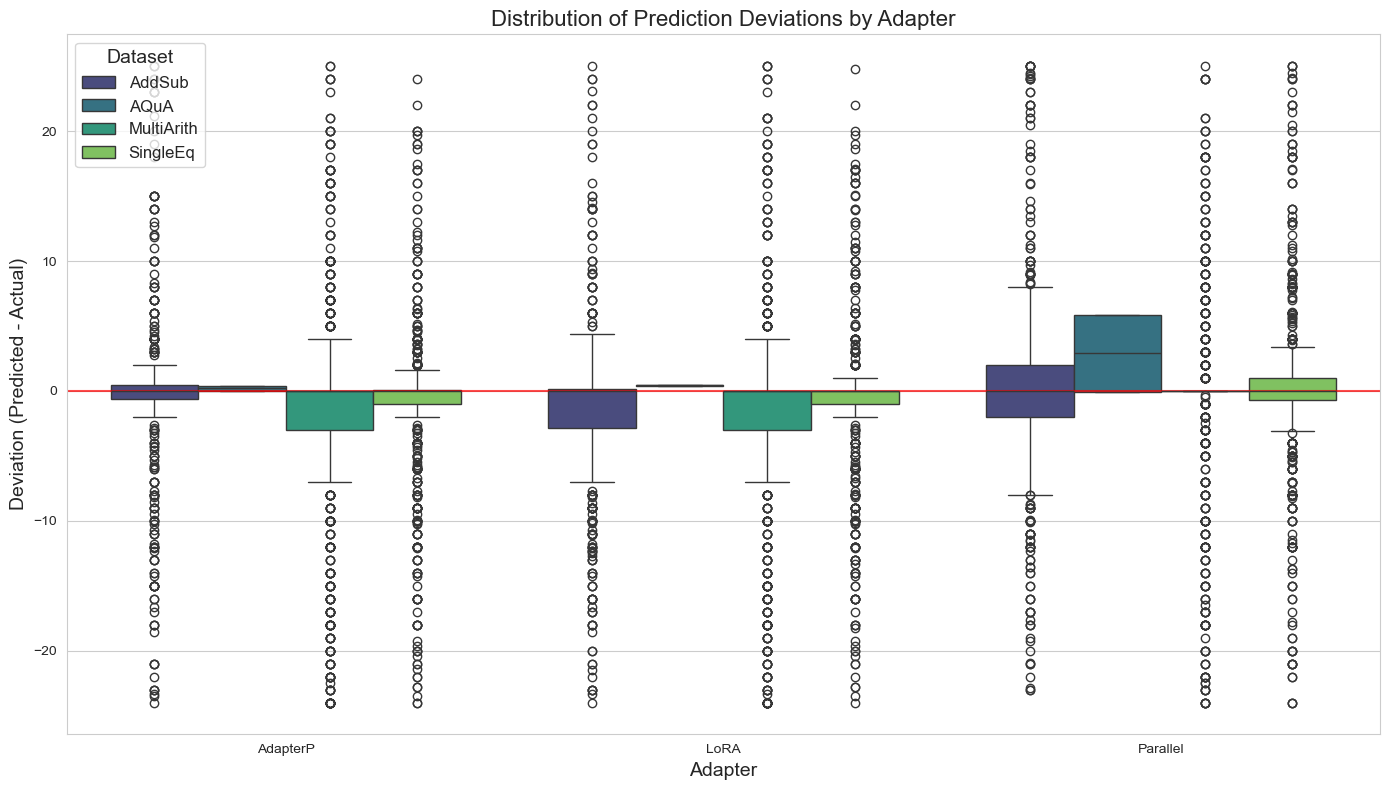

5. Performance by Mathematical Operation...


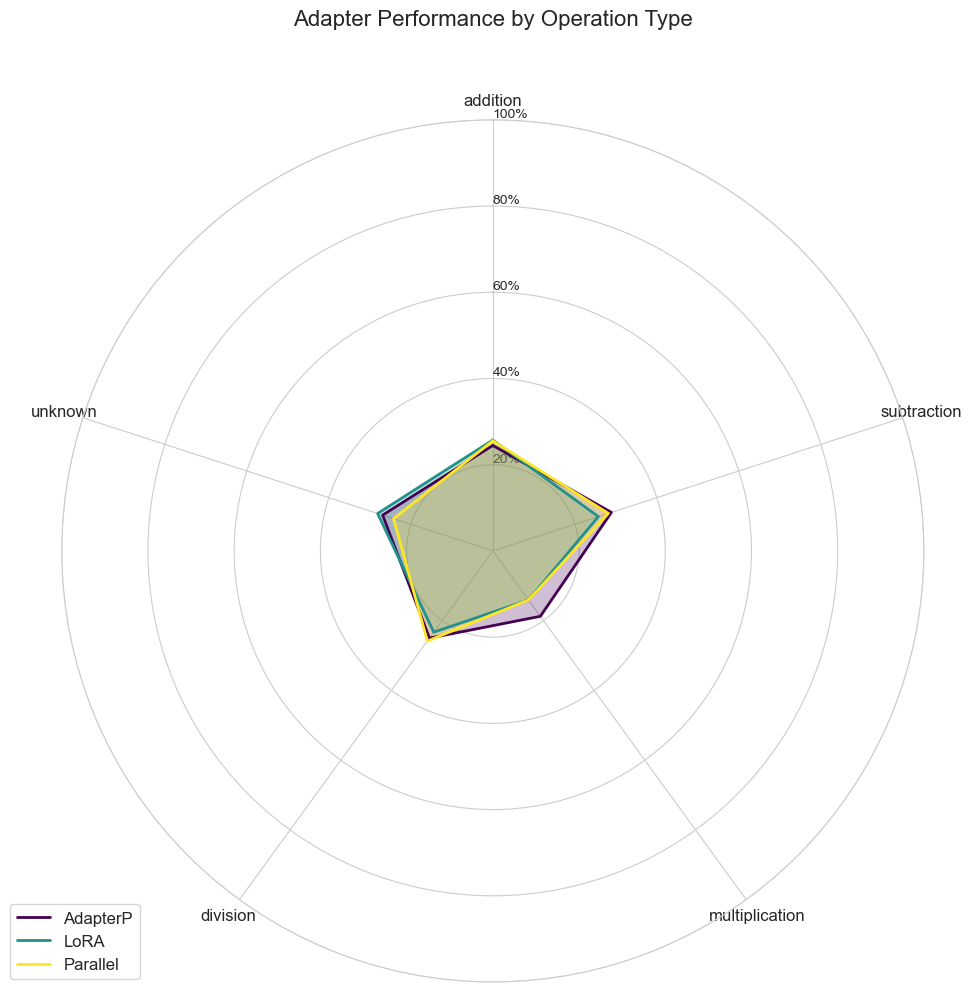

6. Model-Adapter Performance Heatmap...


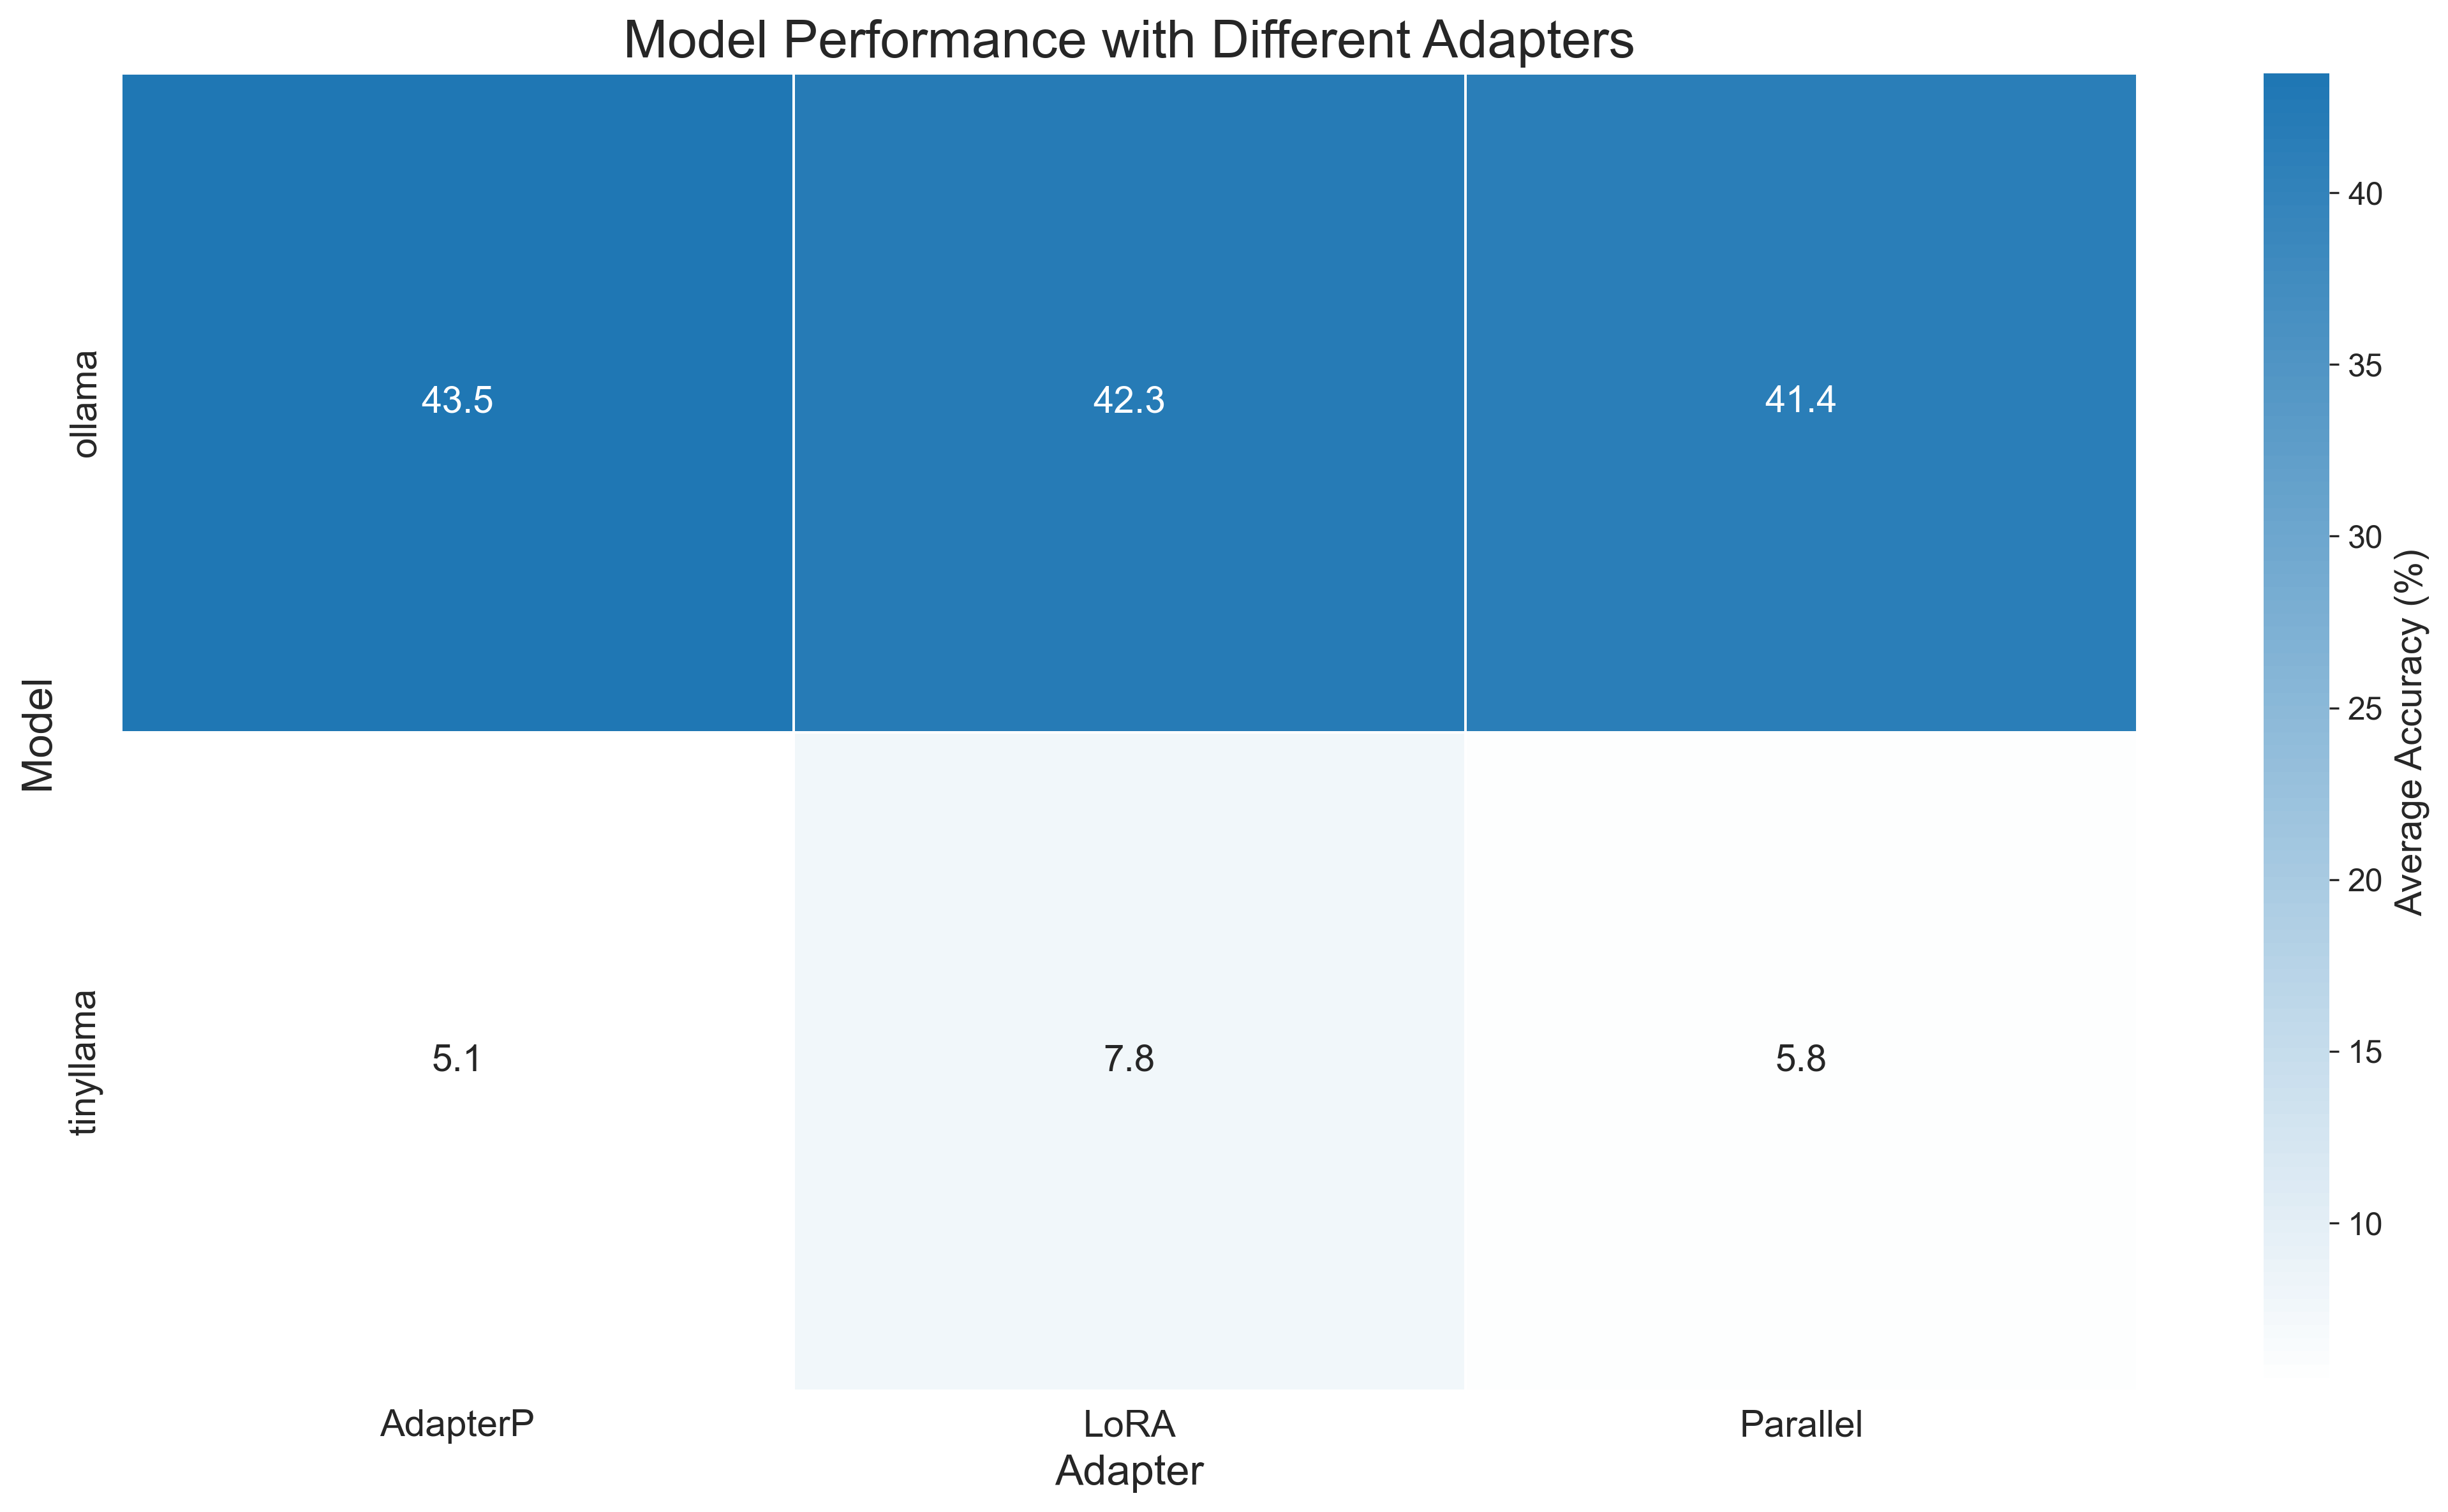

7. Model Performance by Dataset...


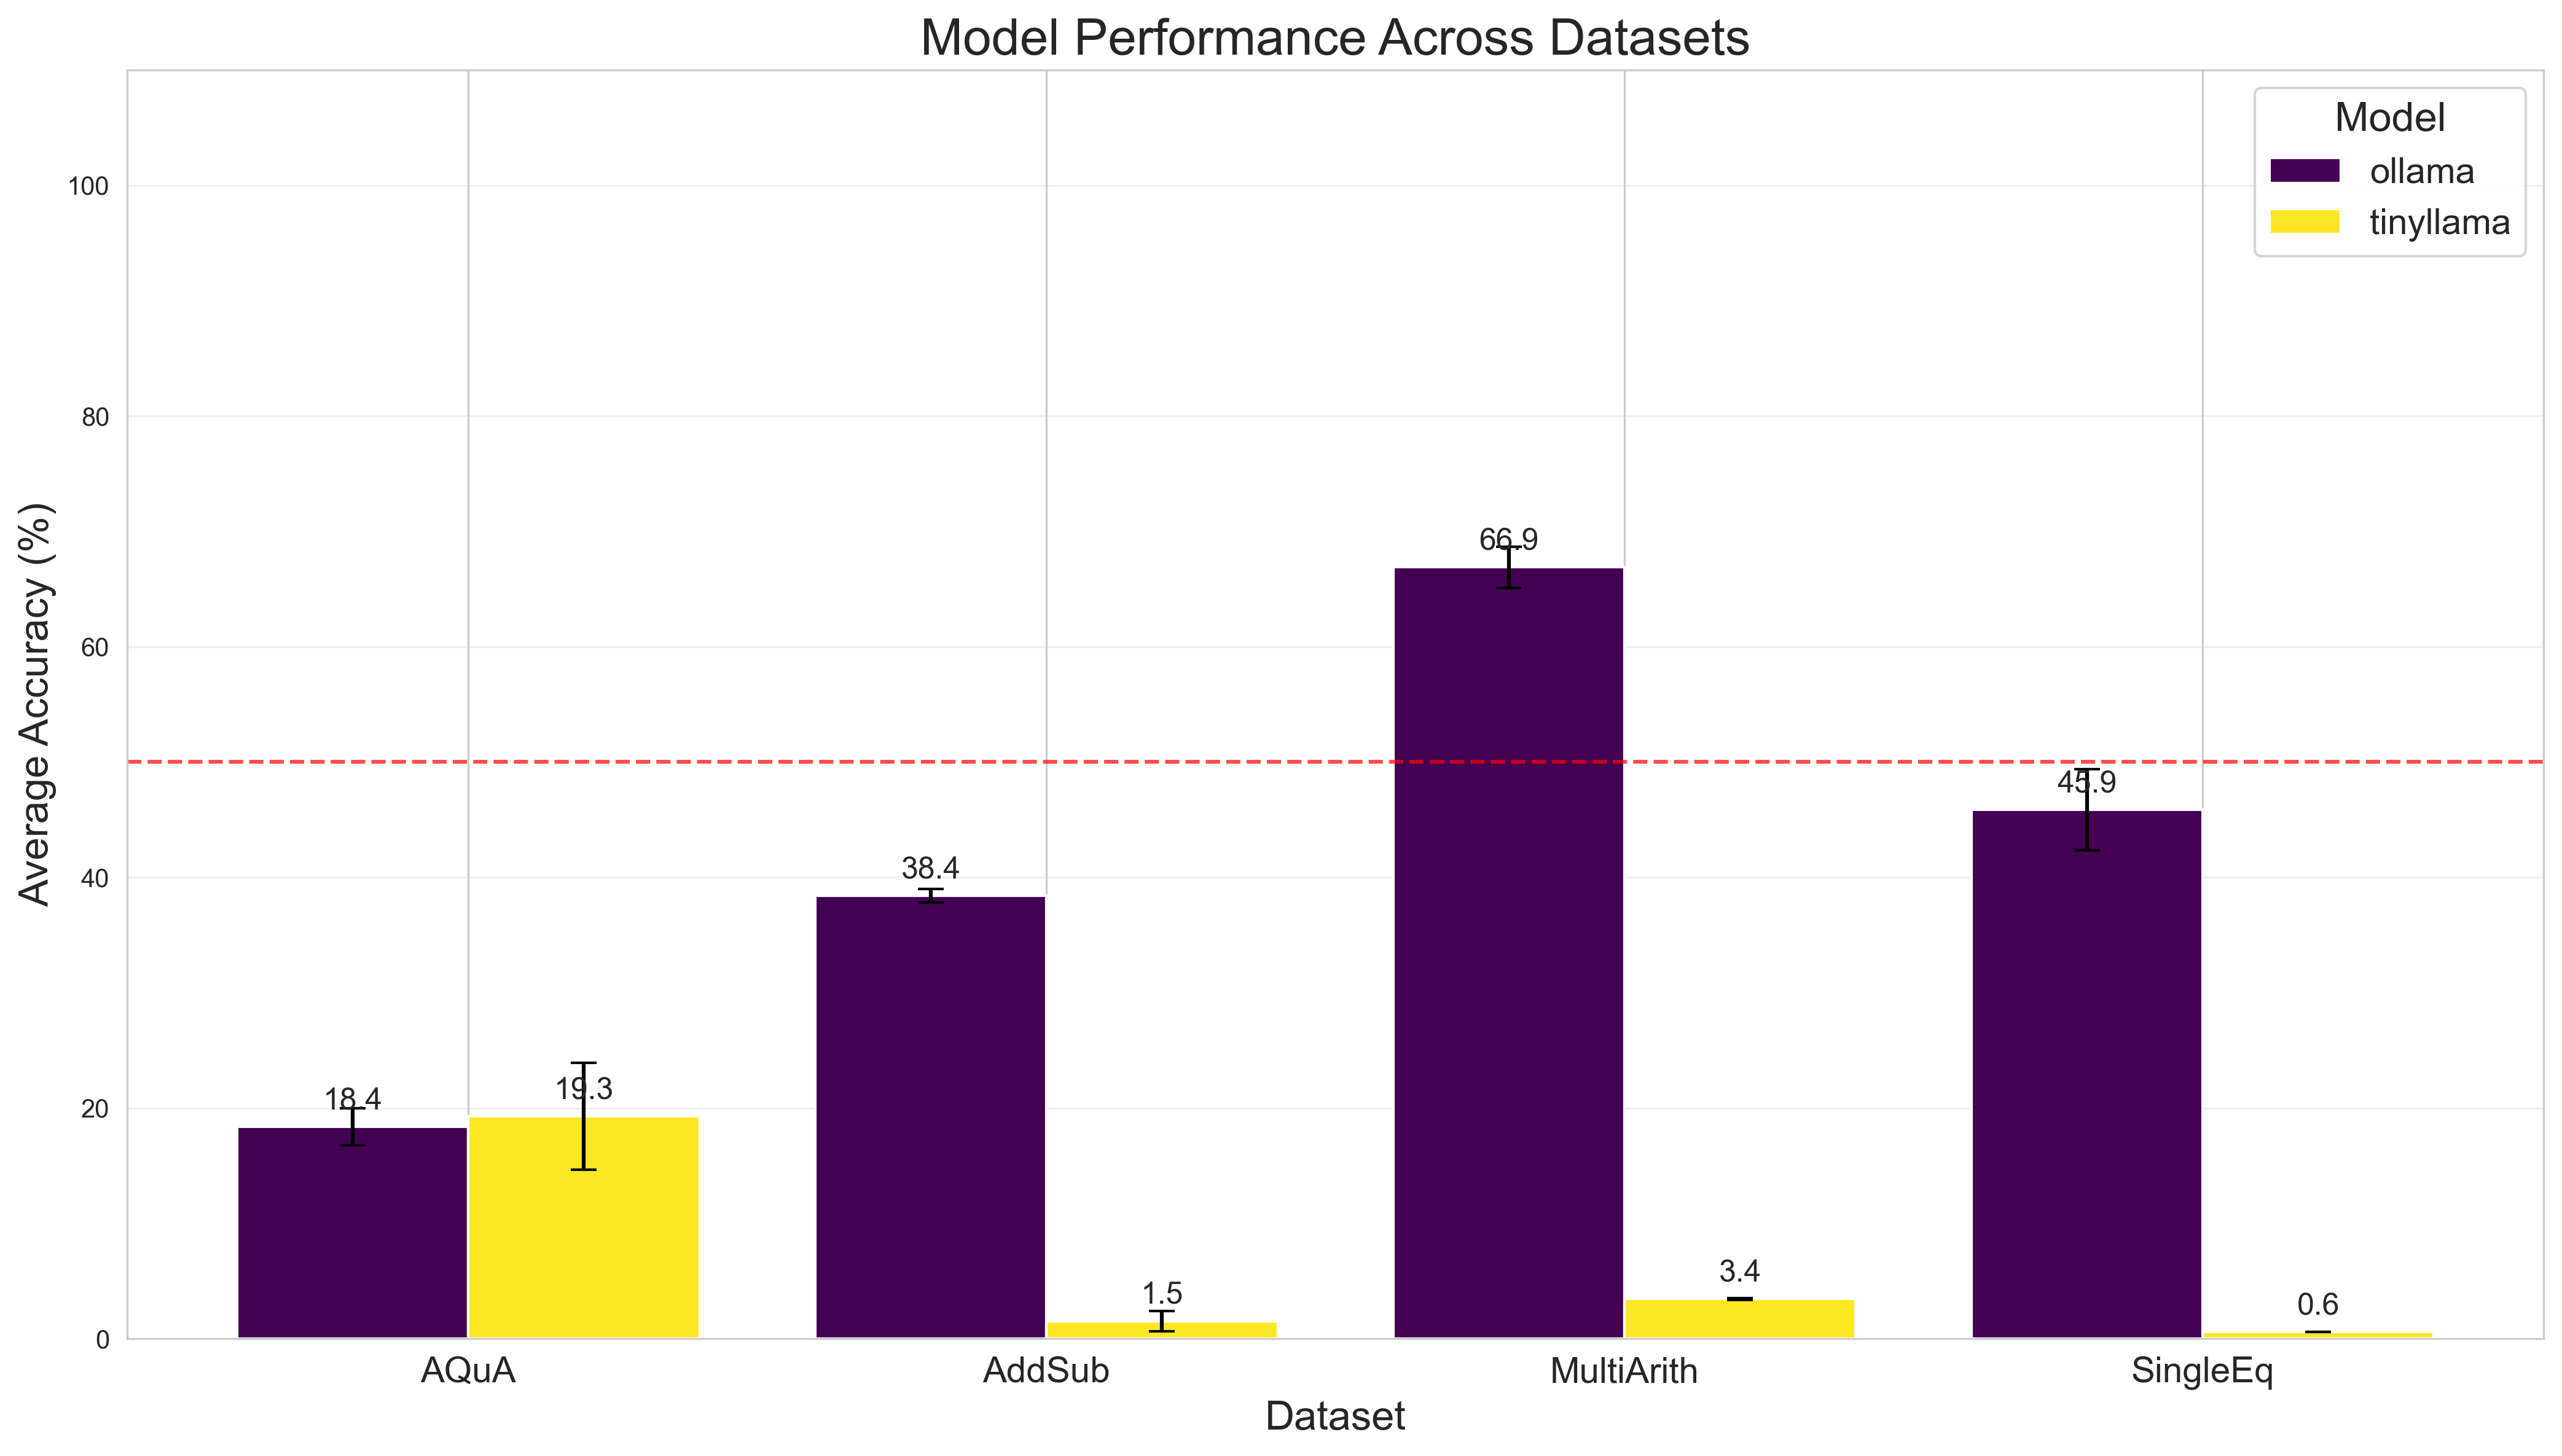

Visualizations saved to ./visualizations


In [14]:
if __name__ == "__main__":
    main()